# Notebook 07: Candidate Models and Hyperparameter Tuning

**Project:** NFL Wide Receiver Performance and Contract Value Analysis  
**Authors:** William Reed and Jason Kuzmission  
**Primary Notebook Developer:** William Reed  

## Purpose

This notebook extends the baseline modeling work from Notebook 06 by
evaluating additional tunable machine learning models for predicting
next season NFL wide receiver receiving yards.

The analysis uses the same finalized modeling dataset and preserves the
player grouped validation strategy established earlier in the project.
Grouping by player prevents observations from the same player from appearing
in both training and testing data, reducing the risk of data leakage and
providing a more realistic estimate of performance on unseen players.

The objective is to determine whether a tuned nonlinear model improves
predictive performance over the baseline approaches while maintaining
appropriate controls for overfitting and data leakage.

In [90]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [91]:
def evaluate_model(y_true, y_pred):
    """Calculate regression evaluation metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [92]:
# Load the finalized modeling dataset
data_path = Path("../data/processed/wr_model.csv")

wr_model = pl.read_csv(data_path)

print(f"Dataset shape: {wr_model.shape}")
print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width:,}")

required_columns = [
    "player_id",
    "receiving_yards",
    "next_season_receiving_yards",
]

for column in required_columns:
    assert column in wr_model.columns, f"{column} is missing from the dataset."

print("Required columns verified.")

Dataset shape: (2129, 139)
Rows: 2,129
Columns: 139
Required columns verified.


In [93]:
groups = wr_model["player_id"].to_numpy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(wr_model, groups=groups)
)

In [94]:
# Define predictors, target, grouping variable, and excluded features

target_column = "next_season_receiving_yards"
group_column = "player_id"

features_to_drop = [
    "passing_cpoe",
    "passing_epa",
    "pacr"
]

predictor_columns = [
    column
    for column in wr_model.columns
    if column not in [
        target_column,
        group_column,
        *features_to_drop
    ]
]

print(f"Predictor variables: {len(predictor_columns)}")
print(f"Target: {target_column}")
print(f"Grouping variable: {group_column}")

print("\nExcluded high missingness predictors:")
for feature in features_to_drop:
    print(f"• {feature}")

assert len(predictor_columns) == 134, (
    f"Expected 134 predictors, found {len(predictor_columns)}."
)

assert target_column not in predictor_columns
assert group_column not in predictor_columns

for feature in features_to_drop:
    assert feature not in predictor_columns

print("\nPredictor definition verified.")

Predictor variables: 134
Target: next_season_receiving_yards
Grouping variable: player_id

Excluded high missingness predictors:
• passing_cpoe
• passing_epa
• pacr

Predictor definition verified.


In [95]:
# Create grouped training and testing datasets

train_data = wr_model[train_idx]
test_data = wr_model[test_idx]

train_players = set(train_data["player_id"].to_list())
test_players = set(test_data["player_id"].to_list())

player_overlap = train_players.intersection(test_players)

print(f"Training observations: {train_data.height:,}")
print(f"Testing observations: {test_data.height:,}")
print(f"Training players: {len(train_players)}")
print(f"Testing players: {len(test_players)}")
print(f"Player overlap: {len(player_overlap)}")

assert len(player_overlap) == 0, "Players overlap between training and testing sets."

Training observations: 1,686
Testing observations: 443
Training players: 496
Testing players: 124
Player overlap: 0


In [96]:
# Create predictor and target datasets

X_train = train_data.select(predictor_columns)
X_test = test_data.select(predictor_columns)

y_train = train_data[target_column].to_numpy()
y_test = test_data[target_column].to_numpy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train observations: {len(y_train):,}")
print(f"y_test observations: {len(y_test):,}")

assert X_train.width == 134
assert X_test.width == 134
assert X_train.height == len(y_train)
assert X_test.height == len(y_test)

print("Feature and target datasets verified.")

X_train shape: (1686, 134)
X_test shape: (443, 134)
y_train observations: 1,686
y_test observations: 443
Feature and target datasets verified.


In [97]:
# Median imputation using training data only

median_imputer = SimpleImputer(strategy="median")

X_train_imputed = median_imputer.fit_transform(
    X_train.to_numpy()
)

X_test_imputed = median_imputer.transform(
    X_test.to_numpy()
)

print(f"Training shape after imputation: {X_train_imputed.shape}")
print(f"Testing shape after imputation: {X_test_imputed.shape}")

print(
    f"Training missing values after imputation: "
    f"{np.isnan(X_train_imputed).sum():,}"
)

print(
    f"Testing missing values after imputation: "
    f"{np.isnan(X_test_imputed).sum():,}"
)

assert X_train_imputed.shape == X_train.shape
assert X_test_imputed.shape == X_test.shape
assert np.isnan(X_train_imputed).sum() == 0
assert np.isnan(X_test_imputed).sum() == 0

print("Median imputation verified.")

Training shape after imputation: (1686, 134)
Testing shape after imputation: (443, 134)
Training missing values after imputation: 0
Testing missing values after imputation: 0
Median imputation verified.


## Baseline Model Results

The baseline results from Notebook 06 provide the benchmark for the candidate models evaluated in this notebook.

| Model | MAE | RMSE | R squared |

| Historical Persistence | 232.32 | 323.76 | 0.421 |

| Multiple Linear Regression | 224.57 | 304.43 | 0.488 |

Multiple linear regression outperformed historical persistence on all three evaluation metrics. It therefore serves as the primary benchmark for evaluating the nonlinear models.

## Random Forest Regression

We will first fit a basic Random Forest model using the same training and testing data used for the baseline models. This gives us an initial result before making any changes to the model's hyperparameters.

In [98]:
# Fit an initial Random Forest model

random_forest = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_imputed, y_train)

rf_predictions = random_forest.predict(X_test_imputed)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R-squared: {rf_r2:.3f}")

Random Forest MAE: 221.98
Random Forest RMSE: 297.67
Random Forest R-squared: 0.510


In [99]:
# Evaluate Random Forest training performance

rf_train_predictions = random_forest.predict(X_train_imputed)

rf_train_mae = mean_absolute_error(y_train, rf_train_predictions)
rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_predictions)
)
rf_train_r2 = r2_score(y_train, rf_train_predictions)

print(f"Training MAE: {rf_train_mae:.2f}")
print(f"Training RMSE: {rf_train_rmse:.2f}")
print(f"Training R-squared: {rf_train_r2:.3f}")

print("\nHeld-out Test Performance")
print(f"Test MAE: {rf_mae:.2f}")
print(f"Test RMSE: {rf_rmse:.2f}")
print(f"Test R-squared: {rf_r2:.3f}")

Training MAE: 77.59
Training RMSE: 101.45
Training R-squared: 0.934

Held-out Test Performance
Test MAE: 221.98
Test RMSE: 297.67
Test R-squared: 0.510


### Random Forest Results

The initial Random Forest improved on both the historical persistence baseline and Multiple Linear Regression.

On the held out test set, the Random Forest achieved an MAE of 221.98 yards, an RMSE of 297.67 yards, and an R squared of 0.510.

These results indicate that nonlinear relationships and interactions among the predictors provide additional predictive value beyond the linear model. The Random Forest will therefore be tuned using grouped cross validation while preserving the held out test set for final evaluation.

In [100]:
# Set up grouped cross-validation for Random Forest tuning

train_groups = train_data[group_column].to_numpy()

group_cv = GroupKFold(n_splits=5)

print(f"Cross-validation folds: {group_cv.get_n_splits()}")
print(f"Training observations available for tuning: {len(y_train):,}")
print(f"Unique training players: {len(np.unique(train_groups)):,}")

assert len(train_groups) == len(y_train)
assert len(np.unique(train_groups)) == 496

print("Grouped cross-validation setup verified.")

Cross-validation folds: 5
Training observations available for tuning: 1,686
Unique training players: 496
Grouped cross-validation setup verified.


In [101]:
# Define Random Forest hyperparameter search space

rf_param_grid = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

total_combinations = (
    len(rf_param_grid["max_depth"])
    * len(rf_param_grid["min_samples_split"])
    * len(rf_param_grid["min_samples_leaf"])
    * len(rf_param_grid["max_features"])
)

print(f"Random Forest parameter combinations: {total_combinations}")

Random Forest parameter combinations: 108


In [102]:
# Build leakage-safe Random Forest tuning pipeline

rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]
)

rf_search_params = {
    "model__max_depth": rf_param_grid["max_depth"],
    "model__min_samples_split": rf_param_grid["min_samples_split"],
    "model__min_samples_leaf": rf_param_grid["min_samples_leaf"],
    "model__max_features": rf_param_grid["max_features"],
}

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


In [103]:
# Configure grouped Random Forest hyperparameter search

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_search_params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

print("Random Forest randomized search configured.")
print("Parameter combinations to test: 20")
print("Grouped CV folds: 5")
print("Total model fits: 100")

Random Forest randomized search configured.
Parameter combinations to test: 20
Grouped CV folds: 5
Total model fits: 100


In [104]:
# Run grouped Random Forest hyperparameter search

rf_search.fit(
    X_train.to_numpy(),
    y_train,
    groups=train_groups
)

print("Random Forest tuning completed.")

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

best_cv_mae = -rf_search.best_score_

print(f"\nBest grouped CV MAE: {best_cv_mae:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest tuning completed.

Best parameters:
model__min_samples_split: 10
model__min_samples_leaf: 5
model__max_features: sqrt
model__max_depth: 15

Best grouped CV MAE: 208.54


In [105]:
# Evaluate tuned Random Forest on held-out test data

best_rf = rf_search.best_estimator_

tuned_rf_predictions = best_rf.predict(X_test.to_numpy())

tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_predictions)
tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_rf_predictions)
)
tuned_rf_r2 = r2_score(y_test, tuned_rf_predictions)

print(f"Tuned Random Forest MAE: {tuned_rf_mae:.2f}")
print(f"Tuned Random Forest RMSE: {tuned_rf_rmse:.2f}")
print(f"Tuned Random Forest R-squared: {tuned_rf_r2:.3f}")

Tuned Random Forest MAE: 219.94
Tuned Random Forest RMSE: 295.65
Tuned Random Forest R-squared: 0.517


In [106]:
# Compare tuned Random Forest training and testing performance

tuned_rf_train_predictions = best_rf.predict(X_train.to_numpy())

tuned_rf_train_mae = mean_absolute_error(
    y_train,
    tuned_rf_train_predictions
)

tuned_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_rf_train_predictions
    )
)

tuned_rf_train_r2 = r2_score(
    y_train,
    tuned_rf_train_predictions
)

print(f"Tuned Training MAE: {tuned_rf_train_mae:.2f}")
print(f"Tuned Training RMSE: {tuned_rf_train_rmse:.2f}")
print(f"Tuned Training R-squared: {tuned_rf_train_r2:.3f}")

print("\nTuned Held-out Test Performance")
print(f"Test MAE: {tuned_rf_mae:.2f}")
print(f"Test RMSE: {tuned_rf_rmse:.2f}")
print(f"Test R-squared: {tuned_rf_r2:.3f}")

Tuned Training MAE: 151.21
Tuned Training RMSE: 198.68
Tuned Training R-squared: 0.747

Tuned Held-out Test Performance
Test MAE: 219.94
Test RMSE: 295.65
Test R-squared: 0.517


### Tuned Random Forest Results

The tuned Random Forest improved on the initial Random Forest and produced the strongest held out performance among the candidate tree based models.

On the held out test set, the tuned Random Forest achieved an MAE of 219.94 yards, an RMSE of 295.65 yards, and an R squared of 0.517.

The initial Random Forest achieved an MAE of 221.98 yards, an RMSE of 297.67 yards, and an R squared of 0.510. Hyperparameter tuning therefore improved all three held out evaluation metrics.

The tuned Random Forest is retained as the leading candidate model for comparison with Gradient Boosting.

## Gradient Boosting Regression

The model will be evaluated using the same player grouped validation strategy and the same MAE, RMSE, and R-squared metrics used for the other models. Hyperparameter decisions will be made using the training data, while the held out test set will remain separate for final evaluation.

In [107]:
# Fit initial Gradient Boosting model

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(
    X_train_imputed,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_test_imputed
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print(f"Gradient Boosting MAE: {gb_mae:.2f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f}")
print(f"Gradient Boosting R-squared: {gb_r2:.3f}")

Gradient Boosting MAE: 227.90
Gradient Boosting RMSE: 306.91
Gradient Boosting R-squared: 0.480


In [108]:
# Compare initial Gradient Boosting training and testing performance

gb_train_predictions = gradient_boosting.predict(
    X_train_imputed
)

gb_train_mae = mean_absolute_error(
    y_train,
    gb_train_predictions
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        gb_train_predictions
    )
)

gb_train_r2 = r2_score(
    y_train,
    gb_train_predictions
)

print(f"Training MAE: {gb_train_mae:.2f}")
print(f"Training RMSE: {gb_train_rmse:.2f}")
print(f"Training R-squared: {gb_train_r2:.3f}")

print("\nHeld-out Test Performance")
print(f"Test MAE: {gb_mae:.2f}")
print(f"Test RMSE: {gb_rmse:.2f}")
print(f"Test R-squared: {gb_r2:.3f}")

Training MAE: 164.56
Training RMSE: 209.98
Training R-squared: 0.718

Held-out Test Performance
Test MAE: 227.90
Test RMSE: 306.91
Test R-squared: 0.480


In [109]:
# Define Gradient Boosting hyperparameter search space

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [3, 5, 10],
}

gb_parameter_combinations = np.prod(
    [len(values) for values in gb_param_grid.values()]
)

print(
    f"Gradient Boosting parameter combinations: "
    f"{gb_parameter_combinations}"
)

Gradient Boosting parameter combinations: 81


In [110]:
# Build leakage-safe Gradient Boosting pipeline

gb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gb_search_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [3, 5, 10],
}

print("Gradient Boosting pipeline configured.")
print(
    "Search-space combinations: "
    f"{np.prod([len(v) for v in gb_search_params.values()])}"
)

Gradient Boosting pipeline configured.
Search-space combinations: 81


In [111]:
# Configure grouped Gradient Boosting hyperparameter search

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_search_params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Gradient Boosting randomized search configured.")
print("Parameter combinations to test: 20")
print("Grouped CV folds: 5")
print("Total model fits: 100")

Gradient Boosting randomized search configured.
Parameter combinations to test: 20
Grouped CV folds: 5
Total model fits: 100


In [112]:
# Run grouped Gradient Boosting hyperparameter search

gb_search.fit(
    X_train.to_numpy(),
    y_train,
    groups=train_groups
)

print("Gradient Boosting tuning completed.")

print("\nBest parameters:")
for parameter, value in gb_search.best_params_.items():
    print(f"{parameter}: {value}")

best_gb_cv_mae = -gb_search.best_score_

print(f"\nBest grouped CV MAE: {best_gb_cv_mae:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting tuning completed.

Best parameters:
model__n_estimators: 300
model__min_samples_leaf: 10
model__max_depth: 2
model__learning_rate: 0.05

Best grouped CV MAE: 207.71


In [113]:
# Evaluate tuned Gradient Boosting on held-out test data

best_gb = gb_search.best_estimator_

tuned_gb_predictions = best_gb.predict(
    X_test.to_numpy()
)

tuned_gb_mae = mean_absolute_error(
    y_test,
    tuned_gb_predictions
)

tuned_gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_gb_predictions
    )
)

tuned_gb_r2 = r2_score(
    y_test,
    tuned_gb_predictions
)

print(f"Tuned Gradient Boosting MAE: {tuned_gb_mae:.2f}")
print(f"Tuned Gradient Boosting RMSE: {tuned_gb_rmse:.2f}")
print(f"Tuned Gradient Boosting R-squared: {tuned_gb_r2:.3f}")

Tuned Gradient Boosting MAE: 224.42
Tuned Gradient Boosting RMSE: 299.33
Tuned Gradient Boosting R-squared: 0.505


In [114]:
# Compare tuned Gradient Boosting training and testing performance

tuned_gb_train_predictions = best_gb.predict(
    X_train.to_numpy()
)

tuned_gb_train_mae = mean_absolute_error(
    y_train,
    tuned_gb_train_predictions
)

tuned_gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_gb_train_predictions
    )
)

tuned_gb_train_r2 = r2_score(
    y_train,
    tuned_gb_train_predictions
)

print(f"Tuned Training MAE: {tuned_gb_train_mae:.2f}")
print(f"Tuned Training RMSE: {tuned_gb_train_rmse:.2f}")
print(f"Tuned Training R-squared: {tuned_gb_train_r2:.3f}")

print("\nTuned Held-out Test Performance")
print(f"Test MAE: {tuned_gb_mae:.2f}")
print(f"Test RMSE: {tuned_gb_rmse:.2f}")
print(f"Test R-squared: {tuned_gb_r2:.3f}")

Tuned Training MAE: 177.73
Tuned Training RMSE: 229.84
Tuned Training R-squared: 0.662

Tuned Held-out Test Performance
Test MAE: 224.42
Test RMSE: 299.33
Test R-squared: 0.505


In [115]:
# Create final held-out model comparison table

model_comparison = pl.DataFrame({
    "model": [
        "Historical Persistence",
        "Multiple Linear Regression",
        "Untuned Random Forest",
        "Tuned Random Forest",
        "Untuned Gradient Boosting",
        "Tuned Gradient Boosting",
    ],
    "mae": [
        232.32,
        224.57,
        rf_mae,
        tuned_rf_mae,
        gb_mae,
        tuned_gb_mae,
    ],
    "rmse": [
        323.76,
        304.43,
        rf_rmse,
        tuned_rf_rmse,
        gb_rmse,
        tuned_gb_rmse,
    ],
    "r_squared": [
        0.421,
        0.488,
        rf_r2,
        tuned_rf_r2,
        gb_r2,
        tuned_gb_r2,
    ],
}).sort("mae")

model_comparison

model,mae,rmse,r_squared
str,f64,f64,f64
"""Tuned Random Forest""",219.937354,295.650167,0.516986
"""Untuned Random Forest""",221.975178,297.665645,0.510378
"""Tuned Gradient Boosting""",224.418582,299.325383,0.504903
"""Multiple Linear Regression""",224.57,304.43,0.488
"""Untuned Gradient Boosting""",227.900662,306.90687,0.479505
"""Historical Persistence""",232.32,323.76,0.421


## Model Comparison and Selection

The tuned Random Forest produced the strongest overall performance on the held out test set. It achieved an MAE of 219.94 yards, an RMSE of 295.65 yards, and an R squared of 0.517.

The tuned Gradient Boosting model achieved an MAE of 224.42 yards, an RMSE of 299.33 yards, and an R squared of 0.505.

Tuned Random Forest produced the lowest MAE, lowest RMSE, and highest R squared among the models evaluated on the held out test set. It was therefore selected as the primary performance model.

In [116]:
# Calculate held-out residuals for the selected model

rf_residuals = (
    y_test
    - tuned_rf_predictions
)

print(f"Mean residual: {np.mean(rf_residuals):.2f}")
print(f"Median residual: {np.median(rf_residuals):.2f}")
print(f"Residual standard deviation: {np.std(rf_residuals):.2f}")

print(f"\nLargest underprediction: {np.max(rf_residuals):.2f}")
print(f"Largest overprediction: {np.min(rf_residuals):.2f}")

Mean residual: 1.76
Median residual: -56.58
Residual standard deviation: 295.64

Largest underprediction: 1154.22
Largest overprediction: -936.19


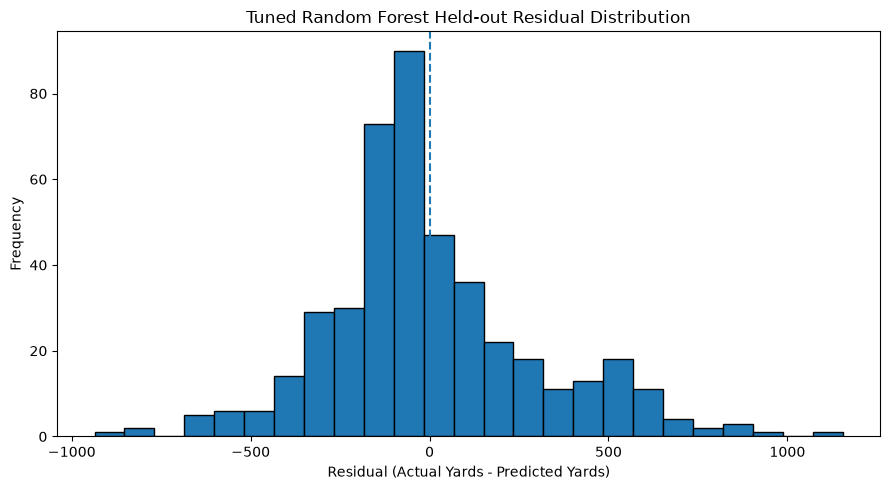

In [117]:
# Plot held-out residual distribution for tuned Random Forest

plt.figure(figsize=(9, 5))

plt.hist(
    rf_residuals,
    bins=25,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Residual (Actual Yards - Predicted Yards)")
plt.ylabel("Frequency")
plt.title("Tuned Random Forest Held-out Residual Distribution")

plt.tight_layout()
plt.show()

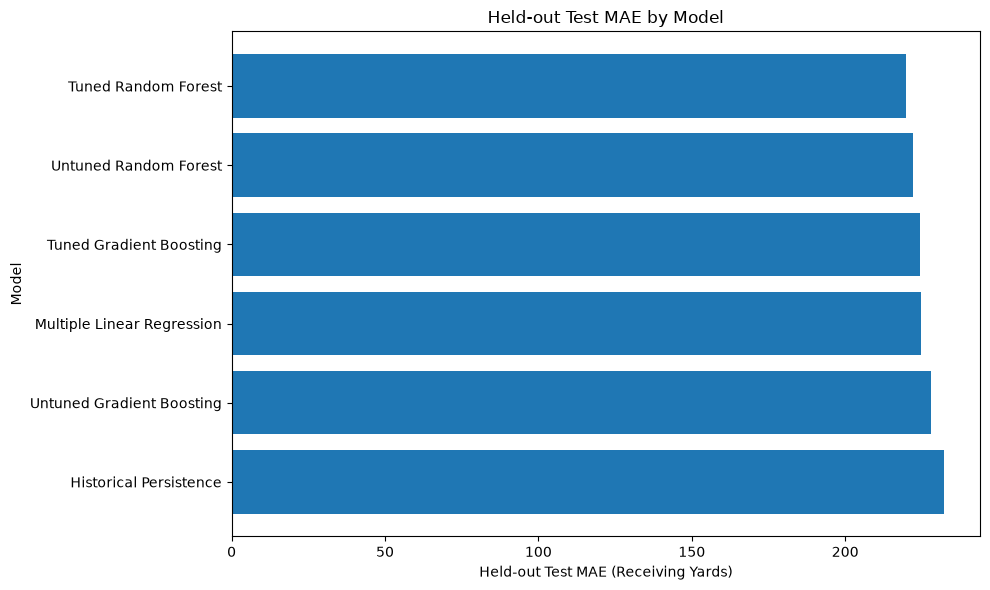

In [118]:
# Plot held-out MAE for all evaluated models

model_names = model_comparison["model"].to_list()
model_mae = model_comparison["mae"].to_list()

plt.figure(figsize=(10, 6))

plt.barh(
    model_names,
    model_mae
)

plt.xlabel("Held-out Test MAE (Receiving Yards)")
plt.ylabel("Model")
plt.title("Held-out Test MAE by Model")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Season Aware Validation

The primary model evaluation uses player grouped splitting and cross validation to prevent the same player from appearing across training and evaluation groups. This controls player leakage but does not establish independence of regression errors.

This additional evaluation tests model performance across time. Earlier seasons are used for training and later seasons are used for testing to better represent how the model would be used to predict future NFL performance. The purpose is to check whether the selected Random Forest remains useful when it must generalize to a future season rather than a randomly selected group of unseen players.

In [119]:
# Check season coverage before creating the season aware validation

season_counts = (
    wr_model
    .group_by("season")
    .agg(
        pl.len().alias("observations"),
        pl.col("player_id").n_unique().alias("players")
    )
    .sort("season")
)

print(season_counts)

shape: (13, 3)
┌────────┬──────────────┬─────────┐
│ season ┆ observations ┆ players │
│ ---    ┆ ---          ┆ ---     │
│ i64    ┆ u32          ┆ u32     │
╞════════╪══════════════╪═════════╡
│ 2012   ┆ 153          ┆ 153     │
│ 2013   ┆ 148          ┆ 148     │
│ 2014   ┆ 150          ┆ 150     │
│ 2015   ┆ 148          ┆ 148     │
│ 2016   ┆ 152          ┆ 152     │
│ …      ┆ …            ┆ …       │
│ 2020   ┆ 187          ┆ 187     │
│ 2021   ┆ 186          ┆ 186     │
│ 2022   ┆ 167          ┆ 167     │
│ 2023   ┆ 173          ┆ 173     │
│ 2024   ┆ 178          ┆ 178     │
└────────┴──────────────┴─────────┘


In [120]:
# Create season aware training and test datasets

season_train = wr_model.filter(
    pl.col("season") < 2024
)

season_test = wr_model.filter(
    pl.col("season") == 2024
)

print("Season aware training observations:", season_train.height)
print("Season aware test observations:", season_test.height)

print(
    "Training seasons:",
    sorted(season_train["season"].unique().to_list())
)

print(
    "Test seasons:",
    sorted(season_test["season"].unique().to_list())
)

assert season_train["season"].max() < season_test["season"].min()

print("Season separation verified.")

Season aware training observations: 1951
Season aware test observations: 178
Training seasons: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test seasons: [2024]
Season separation verified.


In [121]:
# Create season aware predictor and target datasets

X_season_train = season_train.select(predictor_columns)
X_season_test = season_test.select(predictor_columns)

y_season_train = season_train[target_column].to_numpy()
y_season_test = season_test[target_column].to_numpy()

print("Training predictor shape:", X_season_train.shape)
print("Test predictor shape:", X_season_test.shape)

print("Training target observations:", len(y_season_train))
print("Test target observations:", len(y_season_test))

assert X_season_train.shape[0] == len(y_season_train)
assert X_season_test.shape[0] == len(y_season_test)
assert X_season_train.columns == X_season_test.columns

print("Season aware predictor and target datasets verified.")

Training predictor shape: (1951, 134)
Test predictor shape: (178, 134)
Training target observations: 1951
Test target observations: 178
Season aware predictor and target datasets verified.


# Impute season aware predictors using training data only

season_imputer = SimpleImputer(strategy="median")

X_season_train_imputed = season_imputer.fit_transform(
    X_season_train.to_numpy()
)

X_season_test_imputed = season_imputer.transform(
    X_season_test.to_numpy()
)

print("Training shape after imputation:", X_season_train_imputed.shape)
print("Test shape after imputation:", X_season_test_imputed.shape)

print(
    "Training missing values after imputation:",
    np.isnan(X_season_train_imputed).sum()
)

print(
    "Test missing values after imputation:",
    np.isnan(X_season_test_imputed).sum()
)

assert X_season_train_imputed.shape == X_season_train.shape
assert X_season_test_imputed.shape == X_season_test.shape
assert np.isnan(X_season_train_imputed).sum() == 0
assert np.isnan(X_season_test_imputed).sum() == 0

print("Season aware imputation verified.")

In [122]:
season_imputer = SimpleImputer(strategy="median")

X_season_train_imputed = season_imputer.fit_transform(
    X_season_train.to_numpy()
)

X_season_test_imputed = season_imputer.transform(
    X_season_test.to_numpy()
)

print("Training shape after imputation:", X_season_train_imputed.shape)
print("Test shape after imputation:", X_season_test_imputed.shape)

print(
    "Training missing values after imputation:",
    np.isnan(X_season_train_imputed).sum()
)

print(
    "Test missing values after imputation:",
    np.isnan(X_season_test_imputed).sum()
)

assert X_season_train_imputed.shape == X_season_train.shape
assert X_season_test_imputed.shape == X_season_test.shape
assert np.isnan(X_season_train_imputed).sum() == 0
assert np.isnan(X_season_test_imputed).sum() == 0

print("Season aware imputation verified.")

Training shape after imputation: (1951, 134)
Test shape after imputation: (178, 134)
Training missing values after imputation: 0
Test missing values after imputation: 0
Season aware imputation verified.


In [123]:
# Fit the selected Random Forest on earlier seasons only

season_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

season_rf.fit(
    X_season_train_imputed,
    y_season_train
)

print("Season aware Random Forest fitted.")

Season aware Random Forest fitted.


In [124]:
# Evaluate the selected Random Forest on the 2024 future holdout

season_rf_predictions = season_rf.predict(
    X_season_test_imputed
)

season_rf_mae = mean_absolute_error(
    y_season_test,
    season_rf_predictions
)

season_rf_rmse = np.sqrt(
    mean_squared_error(
        y_season_test,
        season_rf_predictions
    )
)

season_rf_r2 = r2_score(
    y_season_test,
    season_rf_predictions
)

print("2024 Future Season Evaluation")
print(f"MAE: {season_rf_mae:.2f} yards")
print(f"RMSE: {season_rf_rmse:.2f} yards")
print(f"R-squared: {season_rf_r2:.3f}")

2024 Future Season Evaluation
MAE: 181.30 yards
RMSE: 247.59 yards
R-squared: 0.567


### Rolling Forward Season Evaluation

A single 2024 holdout provides one test of future season performance but does not show whether the model is stable across different NFL seasons. A rolling evaluation was used as an additional robustness check.

For each evaluation, the model was trained only on seasons that occurred before the test season. The selected Random Forest hyperparameters remained fixed. This prevents future season results from influencing model selection and allows performance to be compared across multiple future season forecasts.

In [125]:
# Rolling future season evaluation

rolling_results = []

test_seasons = [2021, 2022, 2023, 2024]

for test_season in test_seasons:

    # Use only seasons before the season being predicted
    rolling_train = wr_model.filter(
        pl.col("season") < test_season
    )

    rolling_test = wr_model.filter(
        pl.col("season") == test_season
    )

    # Use the same leakage controlled predictors and target
    X_roll_train = rolling_train.select(predictor_columns)
    X_roll_test = rolling_test.select(predictor_columns)

    y_roll_train = rolling_train[target_column].to_numpy()
    y_roll_test = rolling_test[target_column].to_numpy()

    # Learn imputation values from earlier seasons only
    rolling_imputer = SimpleImputer(strategy="median")

    X_roll_train_imputed = rolling_imputer.fit_transform(
        X_roll_train.to_numpy()
    )

    X_roll_test_imputed = rolling_imputer.transform(
        X_roll_test.to_numpy()
    )

    # Use the already selected Random Forest configuration
    rolling_rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )

    rolling_rf.fit(
        X_roll_train_imputed,
        y_roll_train
    )

    rolling_predictions = rolling_rf.predict(
        X_roll_test_imputed
    )

    rolling_mae = mean_absolute_error(
        y_roll_test,
        rolling_predictions
    )

    rolling_rmse = np.sqrt(
        mean_squared_error(
            y_roll_test,
            rolling_predictions
        )
    )

    rolling_r2 = r2_score(
        y_roll_test,
        rolling_predictions
    )

    rolling_results.append({
        "test_season": test_season,
        "outcome_season": test_season + 1,
        "train_through": test_season - 1,
        "train_observations": rolling_train.height,
        "test_observations": rolling_test.height,
        "mae": rolling_mae,
        "rmse": rolling_rmse,
        "r_squared": rolling_r2
    })

rolling_results_df = pl.DataFrame(rolling_results)

print(rolling_results_df)

shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ test_seaso ┆ outcome_se ┆ train_thro ┆ train_obs ┆ test_obse ┆ mae       ┆ rmse      ┆ r_squared │
│ n          ┆ ason       ┆ ugh        ┆ ervations ┆ rvations  ┆ ---       ┆ ---       ┆ ---       │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ f64       ┆ f64       ┆ f64       │
│ i64        ┆ i64        ┆ i64        ┆ i64       ┆ i64       ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2021       ┆ 2022       ┆ 2020       ┆ 1425      ┆ 186       ┆ 201.70258 ┆ 249.96419 ┆ 0.608213  │
│            ┆            ┆            ┆           ┆           ┆ 5         ┆ 4         ┆           │
│ 2022       ┆ 2023       ┆ 2021       ┆ 1611      ┆ 167       ┆ 178.27275 ┆ 235.07708 ┆ 0.69008   │
│            ┆            ┆            ┆           ┆           ┆           ┆ 

In [126]:
# Summarize rolling future season performance

rolling_summary = rolling_results_df.select(
    pl.col("mae").mean().alias("mean_mae"),
    pl.col("mae").std().alias("std_mae"),
    pl.col("rmse").mean().alias("mean_rmse"),
    pl.col("rmse").std().alias("std_rmse"),
    pl.col("r_squared").mean().alias("mean_r_squared"),
    pl.col("r_squared").std().alias("std_r_squared")
)

print(rolling_summary)

shape: (1, 6)
┌────────────┬───────────┬────────────┬──────────┬────────────────┬───────────────┐
│ mean_mae   ┆ std_mae   ┆ mean_rmse  ┆ std_rmse ┆ mean_r_squared ┆ std_r_squared │
│ ---        ┆ ---       ┆ ---        ┆ ---      ┆ ---            ┆ ---           │
│ f64        ┆ f64       ┆ f64        ┆ f64      ┆ f64            ┆ f64           │
╞════════════╪═══════════╪════════════╪══════════╪════════════════╪═══════════════╡
│ 190.172712 ┆ 12.093096 ┆ 246.470761 ┆ 7.941976 ┆ 0.608143       ┆ 0.057955      │
└────────────┴───────────┴────────────┴──────────┴────────────────┴───────────────┘


### Rolling Linear Regression Comparison

Multiple linear regression produced the lowest MAE in the original player grouped holdout, so it remains an important comparison model. The same rolling future season evaluation was applied to linear regression to determine whether its advantage remains when predicting later NFL seasons from earlier seasons.

For each test season, preprocessing was fitted using earlier seasons only. The comparison uses the same predictors, target, future season splits, and evaluation metrics used for Random Forest.

In [127]:
from sklearn.linear_model import LinearRegression

# Rolling future season evaluation for multiple linear regression

linear_rolling_results = []

test_seasons = [2021, 2022, 2023, 2024]

for test_season in test_seasons:

    # Use only seasons before the season being predicted
    rolling_train = wr_model.filter(
        pl.col("season") < test_season
    )

    rolling_test = wr_model.filter(
        pl.col("season") == test_season
    )
    
    X_roll_train = rolling_train.select(predictor_columns)
    X_roll_test = rolling_test.select(predictor_columns)

    y_roll_train = rolling_train[target_column].to_numpy()
    y_roll_test = rolling_test[target_column].to_numpy()

    # Learn imputation values from earlier seasons only
    rolling_imputer = SimpleImputer(strategy="median")

    X_roll_train_imputed = rolling_imputer.fit_transform(
        X_roll_train.to_numpy()
    )

    X_roll_test_imputed = rolling_imputer.transform(
        X_roll_test.to_numpy()
    )

    # Fit multiple linear regression on earlier seasons only
    rolling_linear = LinearRegression()

    rolling_linear.fit(
        X_roll_train_imputed,
        y_roll_train
    )

    linear_predictions = rolling_linear.predict(
        X_roll_test_imputed
    )

    linear_mae = mean_absolute_error(
        y_roll_test,
        linear_predictions
    )

    linear_rmse = np.sqrt(
        mean_squared_error(
            y_roll_test,
            linear_predictions
        )
    )

    linear_r2 = r2_score(
        y_roll_test,
        linear_predictions
    )

    linear_rolling_results.append({
        "test_season": test_season,
        "outcome_season": test_season + 1,
        "train_through": test_season - 1,
        "train_observations": rolling_train.height,
        "test_observations": rolling_test.height,
        "mae": linear_mae,
        "rmse": linear_rmse,
        "r_squared": linear_r2
    })

linear_rolling_results_df = pl.DataFrame(
    linear_rolling_results
)

print(linear_rolling_results_df)

shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ test_seaso ┆ outcome_se ┆ train_thro ┆ train_obs ┆ test_obse ┆ mae       ┆ rmse      ┆ r_squared │
│ n          ┆ ason       ┆ ugh        ┆ ervations ┆ rvations  ┆ ---       ┆ ---       ┆ ---       │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ f64       ┆ f64       ┆ f64       │
│ i64        ┆ i64        ┆ i64        ┆ i64       ┆ i64       ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 2021       ┆ 2022       ┆ 2020       ┆ 1425      ┆ 186       ┆ 195.81348 ┆ 255.68841 ┆ 0.590064  │
│            ┆            ┆            ┆           ┆           ┆ 6         ┆ 8         ┆           │
│ 2022       ┆ 2023       ┆ 2021       ┆ 1611      ┆ 167       ┆ 186.88664 ┆ 243.59603 ┆ 0.66721   │
│            ┆            ┆            ┆           ┆           ┆ 8         ┆ 

In [128]:
# Summarize rolling linear regression performance

linear_rolling_summary = linear_rolling_results_df.select(
    pl.col("mae").mean().alias("mean_mae"),
    pl.col("mae").std().alias("std_mae"),
    pl.col("rmse").mean().alias("mean_rmse"),
    pl.col("rmse").std().alias("std_rmse"),
    pl.col("r_squared").mean().alias("mean_r_squared"),
    pl.col("r_squared").std().alias("std_r_squared")
)

print(linear_rolling_summary)

shape: (1, 6)
┌───────────┬───────────┬────────────┬──────────┬────────────────┬───────────────┐
│ mean_mae  ┆ std_mae   ┆ mean_rmse  ┆ std_rmse ┆ mean_r_squared ┆ std_r_squared │
│ ---       ┆ ---       ┆ ---        ┆ ---      ┆ ---            ┆ ---           │
│ f64       ┆ f64       ┆ f64        ┆ f64      ┆ f64            ┆ f64           │
╞═══════════╪═══════════╪════════════╪══════════╪════════════════╪═══════════════╡
│ 185.19334 ┆ 13.437653 ┆ 247.926614 ┆ 9.426356 ┆ 0.605069       ┆ 0.045735      │
└───────────┴───────────┴────────────┴──────────┴────────────────┴───────────────┘


In [129]:
# Rolling future season evaluation for historical persistence

persistence_rolling_results = []

test_seasons = [2021, 2022, 2023, 2024]

for test_season in test_seasons:

    persistence_test = wr_model.filter(
        pl.col("season") == test_season
    )

    # Historical persistence predicts next season receiving yards
    # using the player's current season receiving yards
    y_persistence_actual = persistence_test[
        target_column
    ].to_numpy()

    y_persistence_pred = persistence_test[
        "receiving_yards"
    ].to_numpy()

    persistence_mae = mean_absolute_error(
        y_persistence_actual,
        y_persistence_pred
    )

    persistence_rmse = np.sqrt(
        mean_squared_error(
            y_persistence_actual,
            y_persistence_pred
        )
    )

    persistence_r2 = r2_score(
        y_persistence_actual,
        y_persistence_pred
    )

    persistence_rolling_results.append({
        "test_season": test_season,
        "outcome_season": test_season + 1,
        "test_observations": persistence_test.height,
        "mae": persistence_mae,
        "rmse": persistence_rmse,
        "r_squared": persistence_r2
    })

persistence_rolling_results_df = pl.DataFrame(
    persistence_rolling_results
)

print(persistence_rolling_results_df)

shape: (4, 6)
┌─────────────┬────────────────┬───────────────────┬────────────┬────────────┬───────────┐
│ test_season ┆ outcome_season ┆ test_observations ┆ mae        ┆ rmse       ┆ r_squared │
│ ---         ┆ ---            ┆ ---               ┆ ---        ┆ ---        ┆ ---       │
│ i64         ┆ i64            ┆ i64               ┆ f64        ┆ f64        ┆ f64       │
╞═════════════╪════════════════╪═══════════════════╪════════════╪════════════╪═══════════╡
│ 2021        ┆ 2022           ┆ 186               ┆ 196.607527 ┆ 272.573567 ┆ 0.534133  │
│ 2022        ┆ 2023           ┆ 167               ┆ 170.694611 ┆ 238.661462 ┆ 0.680556  │
│ 2023        ┆ 2024           ┆ 173               ┆ 216.526012 ┆ 289.753064 ┆ 0.432993  │
│ 2024        ┆ 2025           ┆ 178               ┆ 190.882022 ┆ 271.183455 ┆ 0.481059  │
└─────────────┴────────────────┴───────────────────┴────────────┴────────────┴───────────┘


In [130]:
# Summarize rolling historical persistence performance

persistence_rolling_summary = persistence_rolling_results_df.select(
    pl.col("mae").mean().alias("mean_mae"),
    pl.col("mae").std().alias("std_mae"),
    pl.col("rmse").mean().alias("mean_rmse"),
    pl.col("rmse").std().alias("std_rmse"),
    pl.col("r_squared").mean().alias("mean_r_squared"),
    pl.col("r_squared").std().alias("std_r_squared")
)

print(persistence_rolling_summary)

shape: (1, 6)
┌────────────┬───────────┬────────────┬───────────┬────────────────┬───────────────┐
│ mean_mae   ┆ std_mae   ┆ mean_rmse  ┆ std_rmse  ┆ mean_r_squared ┆ std_r_squared │
│ ---        ┆ ---       ┆ ---        ┆ ---       ┆ ---            ┆ ---           │
│ f64        ┆ f64       ┆ f64        ┆ f64       ┆ f64            ┆ f64           │
╞════════════╪═══════════╪════════════╪═══════════╪════════════════╪═══════════════╡
│ 193.677543 ┆ 18.856188 ┆ 268.042887 ┆ 21.330652 ┆ 0.532185       ┆ 0.107193      │
└────────────┴───────────┴────────────┴───────────┴────────────────┴───────────────┘


### Rolling Validation Results

The rolling evaluation compared tuned Random Forest, multiple linear regression, and historical persistence using predictor seasons from 2021 through 2024. Each model was trained using only seasons before the predictor season being evaluated.

Across the four future season tests, tuned Random Forest produced an average MAE of 190.17 yards, RMSE of 246.47 yards, and R squared of 0.608.

Multiple linear regression produced an average MAE of 185.19 yards, RMSE of 247.93 yards, and R squared of 0.605.

Historical persistence produced an average MAE of 193.68 yards, RMSE of 268.04 yards, and R squared of 0.532.

Linear regression produced the lowest average MAE. Random Forest produced the lowest average RMSE and highest average R squared. Both fitted models improved on historical persistence in RMSE and R squared.

## Notebook 07 Summary

The final evaluation compared historical persistence, multiple linear regression, Random Forest, and Gradient Boosting for predicting next season receiving yards.

The finalized dataset contained 2,129 observations and 134 predictors. Player grouped training, testing, and cross validation prevented the same player from appearing across evaluation groups.

On the held out test set, tuned Random Forest achieved an MAE of 219.94 yards, RMSE of 295.65 yards, and R squared of 0.517. It produced the strongest overall held out performance among the evaluated models.

Season aware validation was also used to evaluate forward prediction. Using 2024 player information to predict 2025 receiving yards, Random Forest achieved an MAE of 181.30 yards, RMSE of 247.59 yards, and R squared of 0.567.

Across four rolling future season evaluations, Random Forest averaged an MAE of 190.17 yards, RMSE of 246.47 yards, and R squared of 0.608. Linear regression averaged an MAE of 185.19 yards, RMSE of 247.93 yards, and R squared of 0.605. Historical persistence averaged an MAE of 193.68 yards, RMSE of 268.04 yards, and R squared of 0.532.

Random Forest was selected as the primary performance model because it produced the strongest held out results and the lowest average rolling RMSE. Linear regression remained competitive and produced the lowest average rolling MAE.

The next stage will combine the finalized performance predictions with salary and contract information. Contract variables will remain outside performance model training so compensation information does not influence the production forecast.